In [44]:
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from numpy.linalg import inv

%matplotlib widget

In [45]:
data = sio.loadmat('ES_II_data.mat')
data.keys()

dict_keys(['__header__', '__version__', '__globals__', 'acceleration_story3', 'acceleration_story5', 'force_story2', 'force_story5'])

In [46]:
acc3 = data['acceleration_story3'].flatten()
acc5 = data['acceleration_story5'].flatten()

f2 = data['force_story2'].flatten()
f5 = data['force_story5'].flatten()

Y_all = np.vstack([acc3, acc5])
U_all = np.vstack([f2, f5])

print("Y_all shape:", Y_all.shape)
print("U_all shape:", U_all.shape)

Y_all shape: (2, 2000)
U_all shape: (2, 2000)


In [47]:
fs = 100
N_half = 1000

# First 10 sec
Y_id = Y_all[:, :N_half]
U_id = U_all[:, :N_half]

# Last 10 sec
Y_pred_true = Y_all[:, N_half:]
U_pred = U_all[:, N_half:]

print(Y_id.shape, U_id.shape)
print(Y_pred_true.shape, U_pred.shape)

(2, 1000) (2, 1000)
(2, 1000) (2, 1000)


Since Part (b), (c), and (d) all require repeated ARX estimation for different orders, the easiest and cleanest way is to first build a reusable function for ARX model that takes order as input.

In [48]:
def ARX_identify(U, Y, p):
    
    r, N = U.shape
    m, _ = Y.shape

    cols = N - p

    # Y matrix
    Y_target = Y[:, p:]

    # V matrix
    V = []

    for k in range(p, N):
        phi = []

        # u(k), u(k-1), ... u(k-p)
        for j in range(p + 1):
            phi.extend(U[:, k-j])

        # y(k-1), ... y(k-p)
        for j in range(1, p+1):
            phi.extend(Y[:, k-j])

        V.append(phi)

    V = np.array(V).T

    theta_hat = Y_target @ V.T @ inv(V @ V.T)

    Y_rec = theta_hat @ V

    return theta_hat, Y_target, V, Y_rec

Part (a)

In [49]:
p = 4

theta_hat, Y_target, V_id, Y_rec = ARX_identify(U_id, Y_id, p)

print("theta_hat shape:", theta_hat.shape)

theta_hat

theta_hat shape: (2, 18)


array([[ 4.04781981e-02,  1.71731104e-02,  5.00775800e-02,
         1.42073345e-01,  1.82770681e-01,  1.42416105e-01,
         1.31319836e-01,  1.64310287e-01, -4.85887898e-02,
         8.05698082e-03,  8.26684258e-01, -1.42076313e-02,
         3.79230902e-01, -1.35062837e-02, -1.95259466e-01,
        -1.93133148e-02, -3.13498949e-01,  1.81791261e-03],
       [-1.20773505e-01,  7.75715906e+00,  1.75183660e-01,
        -5.28265253e+00,  1.20245101e-01, -4.11220458e+00,
         1.50637537e-02, -3.31116774e-01, -1.12214018e-01,
         2.15803441e+00,  3.31921484e-02,  5.98232384e-01,
         1.62606020e-01,  4.18339296e-01, -1.90856408e-01,
        -4.06574370e-02,  3.13756381e-02, -3.34143282e-01]])

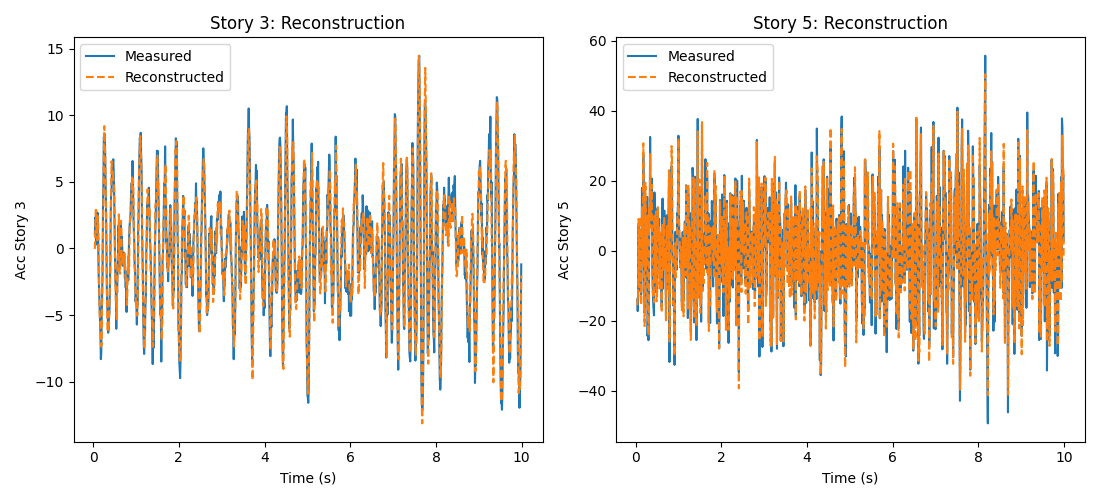

In [50]:
t_id = np.arange(p, 1000) / 100

plt.figure(figsize=(11,5))
plt.subplot(1,2,1)
plt.plot(t_id, Y_target[0], label='Measured')
plt.plot(t_id, Y_rec[0], '--', label='Reconstructed')
plt.xlabel("Time (s)")
plt.ylabel("Acc Story 3")
plt.title("Story 3: Reconstruction")
plt.legend()

plt.subplot(1,2,2)
plt.plot(t_id, Y_target[1], label='Measured')
plt.plot(t_id, Y_rec[1], '--', label='Reconstructed')
plt.xlabel("Time (s)")
plt.ylabel("Acc Story 5")
plt.title("Story 5: Reconstruction")
plt.legend()

plt.tight_layout()
plt.show()

We now use SAME model θ_hat and new inputs/outputs to build validation regressor matrix.

In [51]:
def ARX_predict(U, Y, theta_hat, p):
    r, N = U.shape
    m, _ = Y.shape

    cols = N - p
    Y_true = Y[:, p:]

    V = []

    for k in range(p, N):
        phi = []

        for j in range(p+1):
            phi.extend(U[:, k-j])

        for j in range(1, p+1):
            phi.extend(Y[:, k-j])

        V.append(phi)

    V = np.array(V).T

    Y_pred = theta_hat @ V

    return Y_true, Y_pred

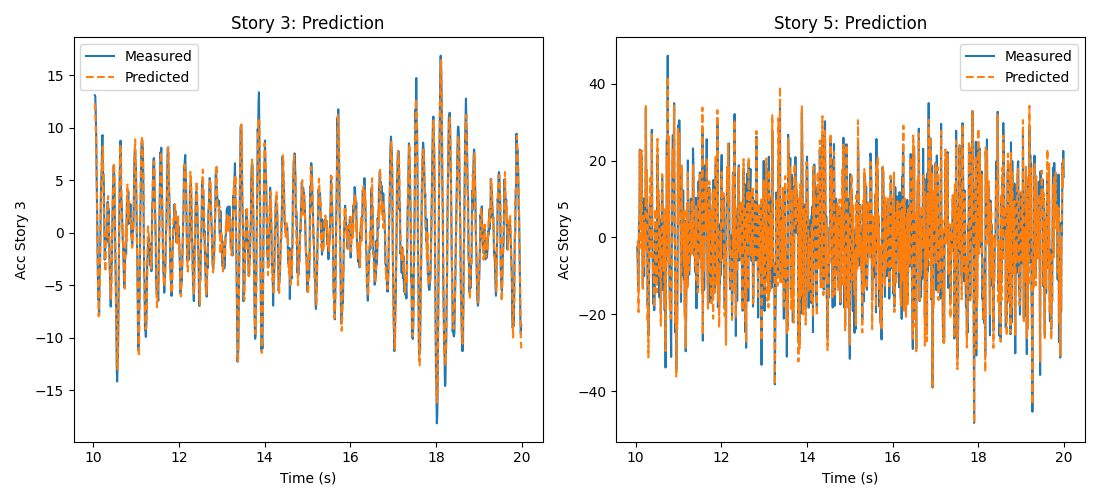

In [52]:
Y_true_pred, Y_pred = ARX_predict(U_pred, Y_pred_true, theta_hat, p)

t_pred = np.arange(p,1000)/100 + 10

plt.figure(figsize=(11,5))
plt.subplot(1,2,1)
plt.plot(t_pred, Y_true_pred[0], label='Measured')
plt.plot(t_pred, Y_pred[0], '--', label='Predicted')
plt.xlabel("Time (s)")
plt.ylabel("Acc Story 3")
plt.title("Story 3: Prediction")
plt.legend()

plt.subplot(1,2,2)
plt.plot(t_pred, Y_true_pred[1], label='Measured')
plt.plot(t_pred, Y_pred[1], '--', label='Predicted')
plt.xlabel("Time (s)")
plt.ylabel("Acc Story 5")
plt.title("Story 5: Prediction")
plt.legend()

plt.tight_layout()
plt.show()

In [53]:
residual = Y_target - Y_rec

RSS = np.sum(residual**2)
SSS = np.sum(Y_target**2)

ratio_residual = RSS / SSS

print("Residual SS / Signal SS =", ratio_residual)

Residual SS / Signal SS = 0.06473829184639798


In [54]:
pred_error = Y_true_pred - Y_pred

PESS = np.sum(pred_error**2)
PSSS = np.sum(Y_true_pred**2)

ratio_pred = PESS / PSSS

print("Prediction Error SS / Signal SS =", ratio_pred)

Prediction Error SS / Signal SS = 0.07436504524000857


Part (b)

In [55]:
orders = np.arange(4,104)

AIC_vals = []
BIC_vals = []
RSS_vals = []

for p in orders:
    
    theta_hat, Y_target, V_id, Y_rec = ARX_identify(U_id, Y_id, p)
    
    residual = Y_target - Y_rec
    RSS = np.sum(residual**2)
    
    # number of observations
    Nobs = Y_target.size
    
    J = RSS / Nobs
    
    # number of parameters
    q = 2*(p+1) + 2*p
    k = 2*q
    
    AIC = Nobs*np.log(J) + 2*k
    BIC = Nobs*np.log(J) + k*np.log(Nobs)
    
    AIC_vals.append(AIC)
    BIC_vals.append(BIC)
    RSS_vals.append(RSS)

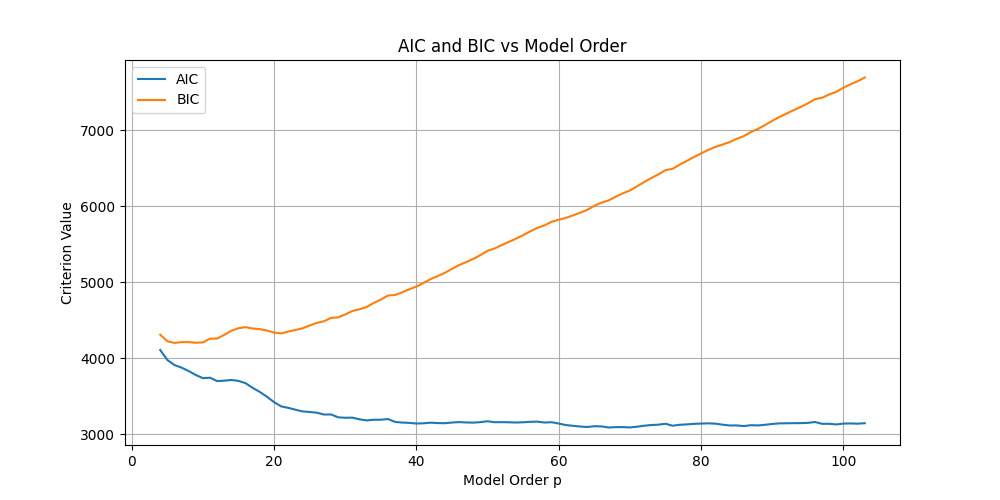

In [56]:
plt.figure(figsize=(10,5))
plt.plot(orders, AIC_vals, label='AIC')
plt.plot(orders, BIC_vals, label='BIC')
plt.xlabel("Model Order p")
plt.ylabel("Criterion Value")
plt.title("AIC and BIC vs Model Order")
plt.legend()
plt.grid(True)
plt.show()

In [57]:
idx = np.argmin(BIC_vals)

best_p = orders[idx]
best_bic = BIC_vals[idx]

print("Minimum BIC at order p =", best_p)
print("Minimum BIC value =", best_bic)

Minimum BIC at order p = 6
Minimum BIC value = 4199.835531824164


Part (c)

In [58]:
orders = np.arange(4,104)

res_ratios = []
pred_ratios = []

for p in orders:
    
    theta_hat, Y_target, V_id, Y_rec = ARX_identify(U_id, Y_id, p)
    
    residual = Y_target - Y_rec
    
    RSS = np.sum(residual**2)
    SSS = np.sum(Y_target**2)
    
    res_ratio = RSS / SSS
    
    # Prediction
    Y_true_pred, Y_pred = ARX_predict(U_pred, Y_pred_true, theta_hat, p)
    
    pred_error = Y_true_pred - Y_pred
    
    PESS = np.sum(pred_error**2)
    PSSS = np.sum(Y_true_pred**2)
    
    pred_ratio = PESS / PSSS
    
    res_ratios.append(res_ratio)
    pred_ratios.append(pred_ratio)

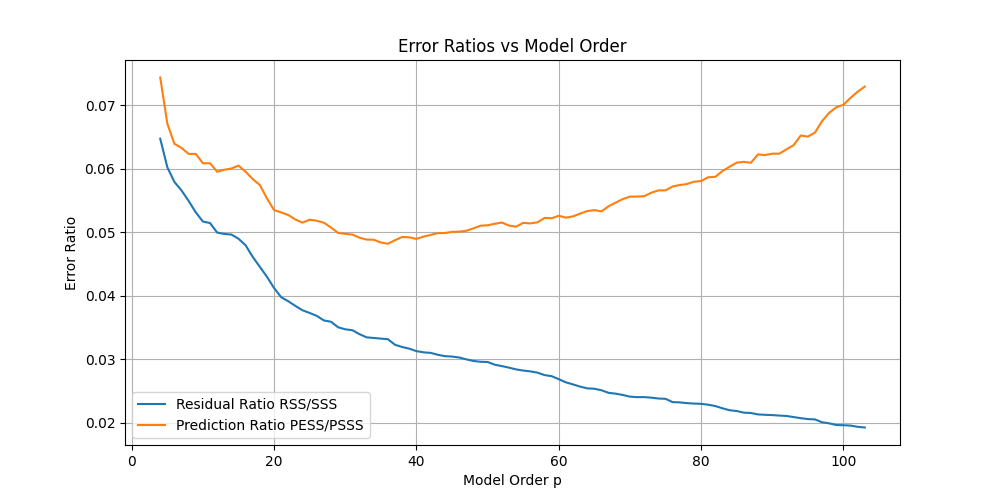

In [59]:
# Plots

plt.figure(figsize=(10,5))
plt.plot(orders, res_ratios, label='Residual Ratio RSS/SSS')
plt.plot(orders, pred_ratios, label='Prediction Ratio PESS/PSSS')
plt.xlabel("Model Order p")
plt.ylabel("Error Ratio")
plt.title("Error Ratios vs Model Order")
plt.legend()
plt.grid(True)
plt.show()

In [60]:
best_pred = orders[np.argmin(pred_ratios)]
print("Minimum prediction ratio at p =", best_pred)

Minimum prediction ratio at p = 36


The residual ratio decreased monotonically with increasing model order, indicating improved fitting on identification data. However, the prediction ratio first decreased and then increased, attaining a minimum near p=36. This demonstrates the bias-variance tradeoff: low-order models underfit, while excessively high-order models overfit. Although BIC selected p=6 as the most efficient model, the best pure predictive performance was obtained near p=36.

Part (d)

In [61]:
p = 6
r = 2
m = 2

U_init = U_id[:, :100]
Y_init = Y_id[:, :100]

theta_old, Y_target_init, V_old, Y_rec = ARX_identify(U_init, Y_init, p)

Q_old = np.linalg.inv(V_old @ V_old.T)

print(theta_old.shape)
print(Q_old.shape)

(2, 26)
(26, 26)


In [62]:
theta_history = []
time_history = []

for k in range(100, 1000):
    
    phi = []
    
    # u(k), u(k-1), ... u(k-p)
    for j in range(p+1):
        phi.extend(U_id[:, k-j])
    
    # y(k-1), ... y(k-p)
    for j in range(1, p+1):
        phi.extend(Y_id[:, k-j])
    
    V_new = np.array(phi).reshape(-1,1)      # (26,1)
    Y_new = Y_id[:, k].reshape(-1,1)         # (2,1)
    
    # denominator
    den = 1 + V_new.T @ Q_old @ V_new
    
    # gain row vector
    gain = (V_new.T @ Q_old) / den
    
    theta_new = theta_old + (Y_new - theta_old @ V_new) @ gain
    
    Q_new = Q_old - (Q_old @ V_new @ V_new.T @ Q_old) / den
    
    theta_old = theta_new
    Q_old = Q_new
    
    theta_history.append(theta_old.copy())
    time_history.append(k/100)

theta_history = np.array(theta_history)

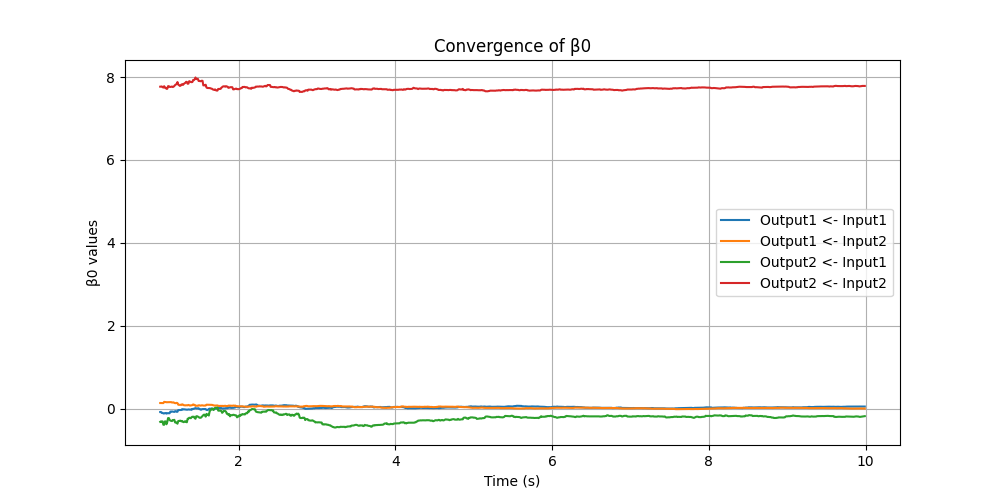

In [63]:
plt.figure(figsize=(10,5))

plt.plot(time_history, theta_history[:,0,0], label='Output1 <- Input1')
plt.plot(time_history, theta_history[:,0,1], label='Output1 <- Input2')
plt.plot(time_history, theta_history[:,1,0], label='Output2 <- Input1')
plt.plot(time_history, theta_history[:,1,1], label='Output2 <- Input2')

plt.xlabel("Time (s)")
plt.ylabel("β0 values")
plt.title("Convergence of β0")
plt.legend()
plt.grid(True)
plt.show()

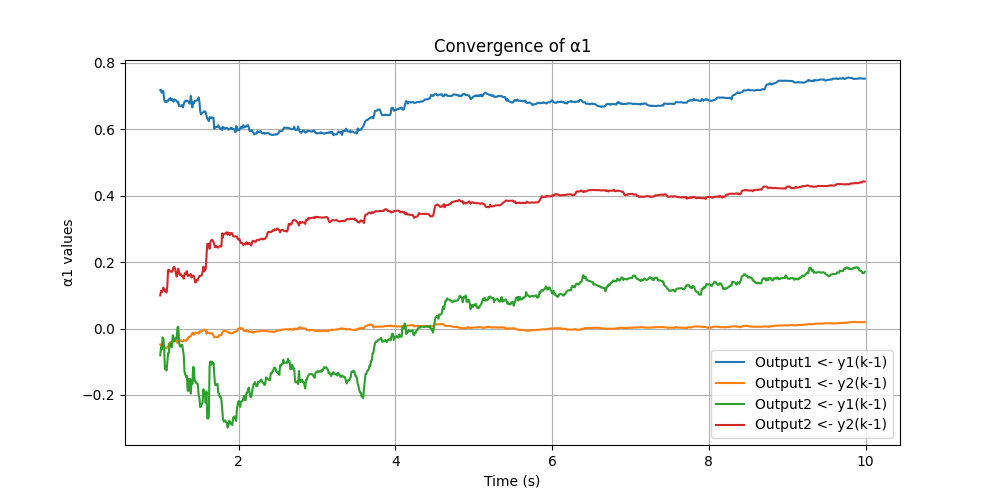

In [64]:
plt.figure(figsize=(10,5))

plt.plot(time_history, theta_history[:,0,14], label='Output1 <- y1(k-1)')
plt.plot(time_history, theta_history[:,0,15], label='Output1 <- y2(k-1)')
plt.plot(time_history, theta_history[:,1,14], label='Output2 <- y1(k-1)')
plt.plot(time_history, theta_history[:,1,15], label='Output2 <- y2(k-1)')

plt.xlabel("Time (s)")
plt.ylabel("α1 values")
plt.title("Convergence of α1")
plt.legend()
plt.grid(True)
plt.show()